In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('dataset/household_power_consumption.txt', sep=';', na_values=['?'], low_memory=False)
df.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


In [3]:

df['Datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], format='%d/%m/%Y %H:%M:%S')
df.drop(['Date', 'Time'], axis=1, inplace=True)
df.head()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,Datetime
0,4.216,0.418,234.84,18.4,0.0,1.0,17.0,2006-12-16 17:24:00
1,5.360,0.436,233.63,23.0,0.0,1.0,16.0,2006-12-16 17:25:00
2,5.374,0.498,233.29,23.0,0.0,2.0,17.0,2006-12-16 17:26:00
3,5.388,0.502,233.74,23.0,0.0,1.0,17.0,2006-12-16 17:27:00
4,3.666,0.528,235.68,15.8,0.0,1.0,17.0,2006-12-16 17:28:00


In [4]:
df.shape

(2075259, 8)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2075259 entries, 0 to 2075258
Data columns (total 8 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   Global_active_power    float64       
 1   Global_reactive_power  float64       
 2   Voltage                float64       
 3   Global_intensity       float64       
 4   Sub_metering_1         float64       
 5   Sub_metering_2         float64       
 6   Sub_metering_3         float64       
 7   Datetime               datetime64[us]
dtypes: datetime64[us](1), float64(7)
memory usage: 126.7 MB


In [6]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
Global_active_power,2049280.0,1.091615,0.076,0.308,0.602,1.528,11.122,1.057294
Global_reactive_power,2049280.0,0.123714,0.0,0.048,0.1,0.194,1.39,0.112722
Voltage,2049280.0,240.839858,223.2,238.99,241.01,242.89,254.15,3.239987
Global_intensity,2049280.0,4.627759,0.2,1.4,2.6,6.4,48.4,4.444396
Sub_metering_1,2049280.0,1.121923,0.0,0.0,0.0,0.0,88.0,6.153031
Sub_metering_2,2049280.0,1.29852,0.0,0.0,0.0,1.0,80.0,5.822026
Sub_metering_3,2049280.0,6.458447,0.0,0.0,1.0,17.0,31.0,8.437154
Datetime,2075259,2008-12-06 07:13:00,2006-12-16 17:24:00,2007-12-12 00:18:30,2008-12-06 07:13:00,2009-12-01 14:07:30,2010-11-26 21:02:00,NaN


In [7]:
df.isnull().sum()

Global_active_power      25979
Global_reactive_power    25979
Voltage                  25979
Global_intensity         25979
Sub_metering_1           25979
Sub_metering_2           25979
Sub_metering_3           25979
Datetime                     0
dtype: int64

In [8]:
df.isnull().sum()/len(df) * 100  # Percentage of missing values

Global_active_power      1.251844
Global_reactive_power    1.251844
Voltage                  1.251844
Global_intensity         1.251844
Sub_metering_1           1.251844
Sub_metering_2           1.251844
Sub_metering_3           1.251844
Datetime                 0.000000
dtype: float64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.set_index('Datetime', inplace=True)
df.head()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
Datetime,,,,,,,
2006-12-16 17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
2006-12-16 17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2006-12-16 17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
2006-12-16 17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
2006-12-16 17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


In [11]:
# Handle Missing Values
print("Missing values before processing:\n", df.isna().sum())

# For time series, interpolation (filling gaps based on surrounding data) is highly effective.
# 'time' method interpolates based on the time index distance.
df = df.interpolate(method='time')

# If there are missing values at the very beginning of the dataset, interpolation won't catch them.
# We use backfill for those edge cases.
df.bfill(inplace=True) 

print("\nMissing values after processing:\n", df.isna().sum())

Missing values before processing:
 Global_active_power      25979
Global_reactive_power    25979
Voltage                  25979
Global_intensity         25979
Sub_metering_1           25979
Sub_metering_2           25979
Sub_metering_3           25979
dtype: int64

Missing values after processing:
 Global_active_power      0
Global_reactive_power    0
Voltage                  0
Global_intensity         0
Sub_metering_1           0
Sub_metering_2           0
Sub_metering_3           0
dtype: int64


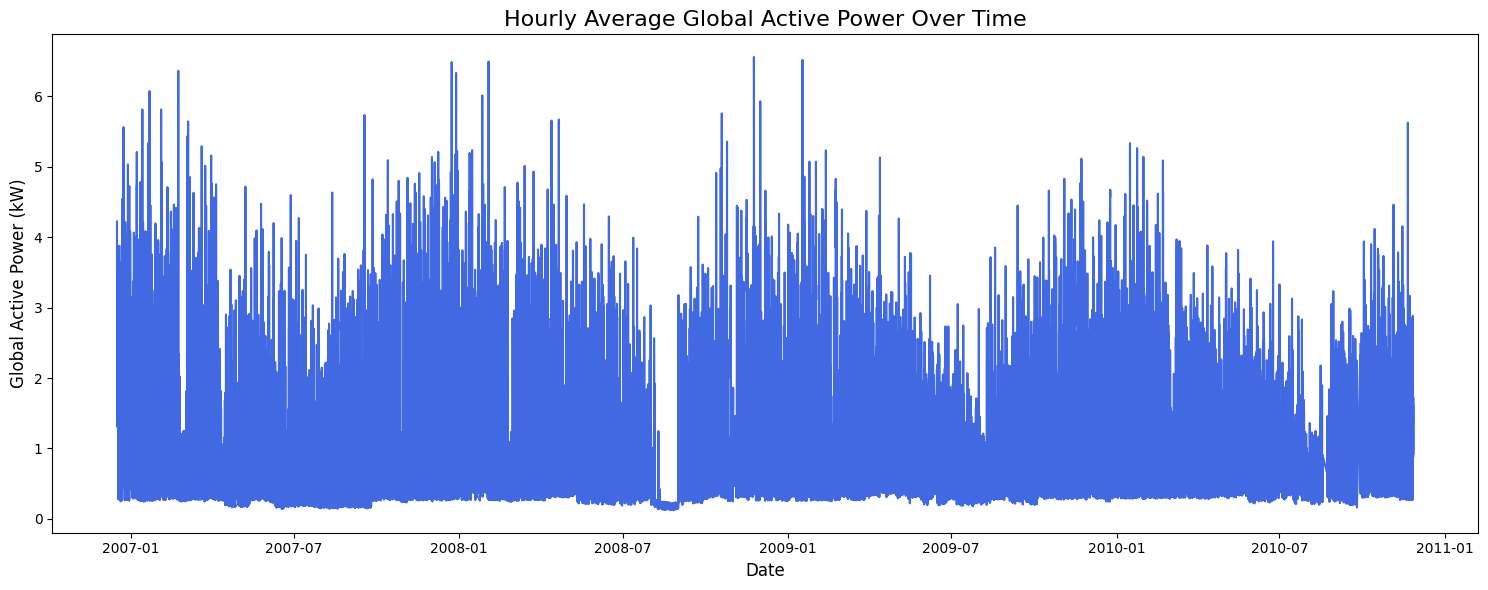

In [12]:
plt.figure(figsize=(15, 6))
# Resample data to hourly ('h') frequency and calculate the mean
daily_data = df['Global_active_power'].resample('h').mean()

plt.plot(daily_data.index, daily_data.values, color='royalblue', linewidth=1.5)
plt.title('Hourly Average Global Active Power Over Time', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Global Active Power (kW)', fontsize=12)
plt.tight_layout()
plt.show()

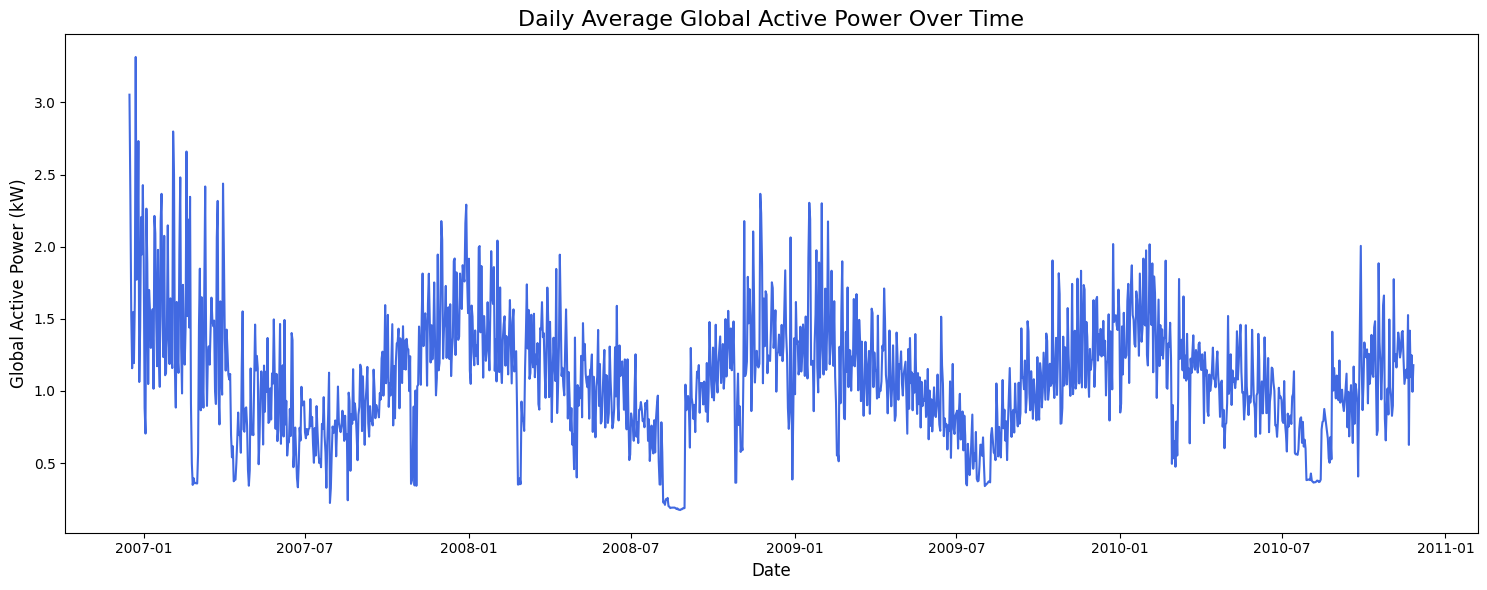

In [13]:
plt.figure(figsize=(15, 6))
# Resample data to Daily ('D') frequency and calculate the mean
daily_data = df['Global_active_power'].resample('D').mean()

plt.plot(daily_data.index, daily_data.values, color='royalblue', linewidth=1.5)
plt.title('Daily Average Global Active Power Over Time', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Global Active Power (kW)', fontsize=12)
plt.tight_layout()
plt.show()

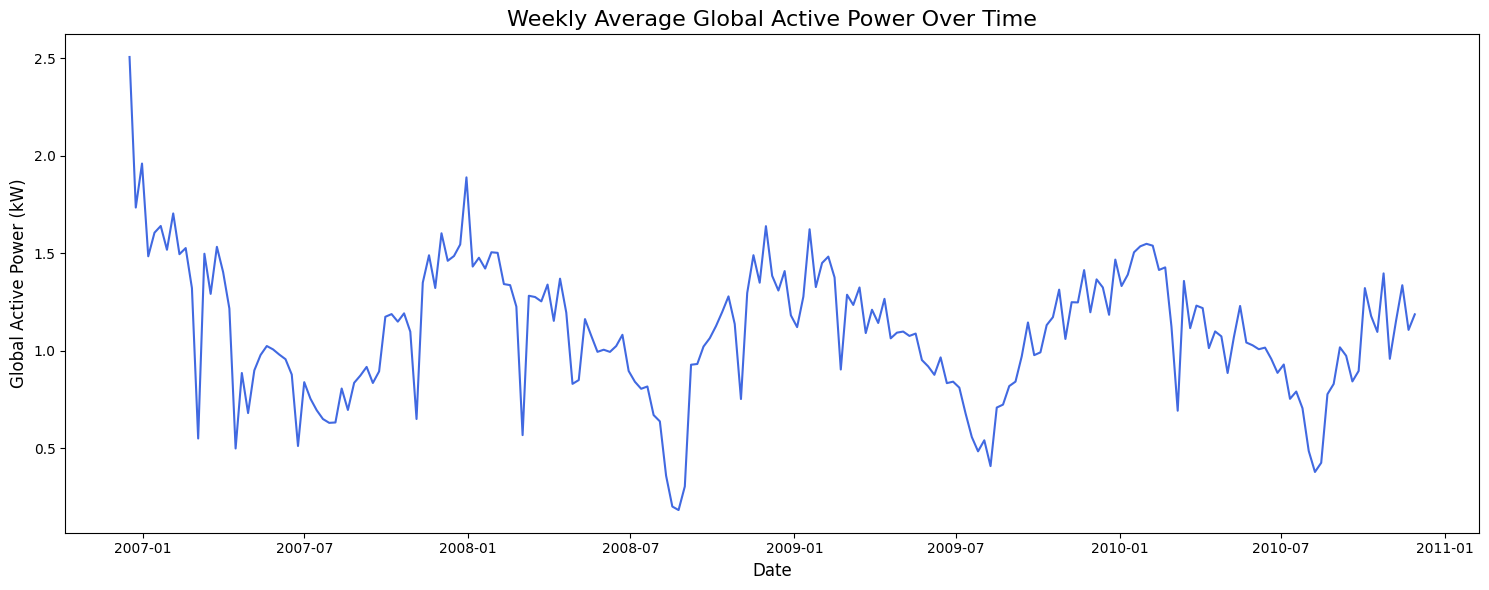

In [14]:
plt.figure(figsize=(15, 6))
# Resample data to weekly ('W') frequency and calculate the mean
daily_data = df['Global_active_power'].resample('W').mean()

plt.plot(daily_data.index, daily_data.values, color='royalblue', linewidth=1.5)
plt.title('Weekly Average Global Active Power Over Time', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Global Active Power (kW)', fontsize=12)
plt.tight_layout()
plt.show()

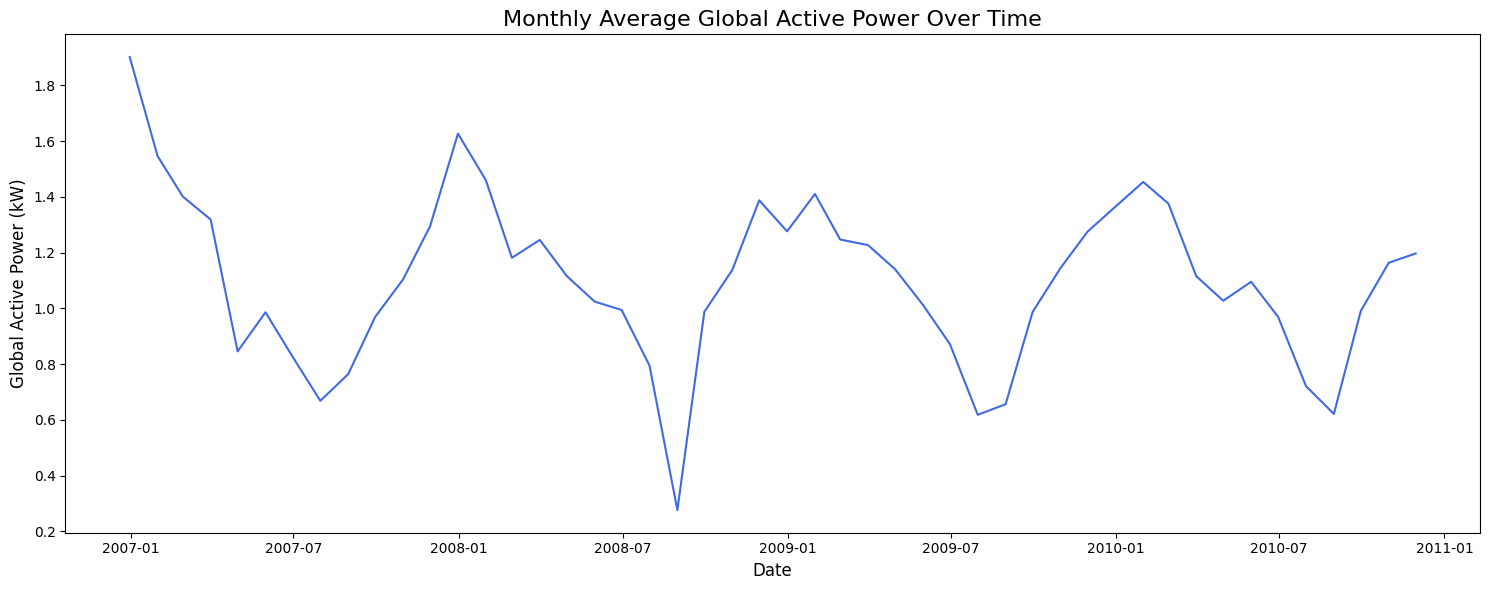

In [15]:
plt.figure(figsize=(15, 6))
# Resample data to monthly ('ME') frequency and calculate the mean
daily_data = df['Global_active_power'].resample('ME').mean()

plt.plot(daily_data.index, daily_data.values, color='royalblue', linewidth=1.5)
plt.title('Monthly Average Global Active Power Over Time', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Global Active Power (kW)', fontsize=12)
plt.tight_layout()
plt.show()

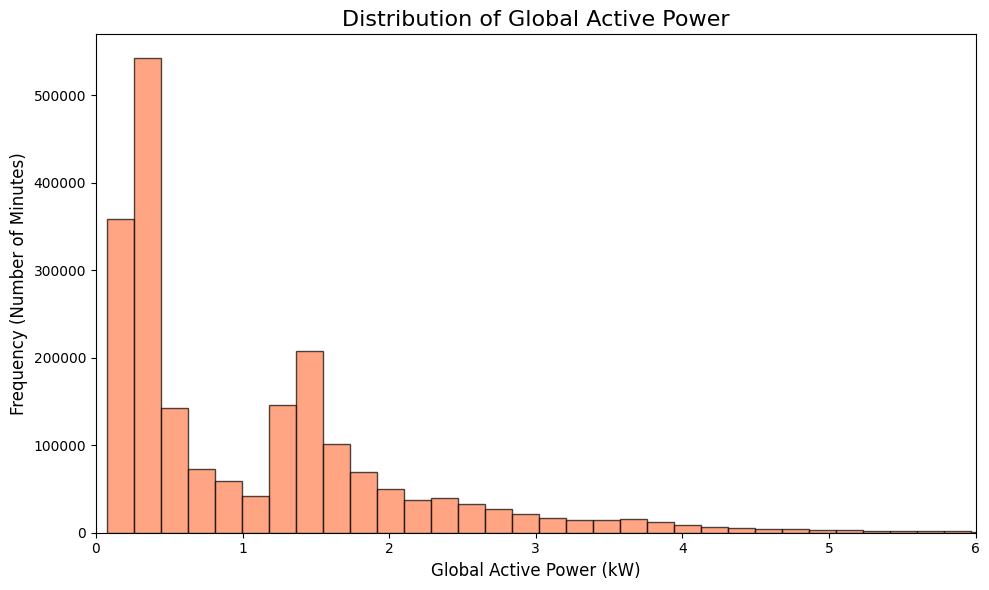

In [16]:
plt.figure(figsize=(10, 6))
plt.hist(df['Global_active_power'], bins=60, color='coral', edgecolor='black', alpha=0.7)
plt.title('Distribution of Global Active Power', fontsize=16)
plt.xlabel('Global Active Power (kW)', fontsize=12)
plt.ylabel('Frequency (Number of Minutes)', fontsize=12)
# Limit x-axis to zoom in on the main distribution
plt.xlim(0, 6) 
plt.tight_layout()
plt.show()

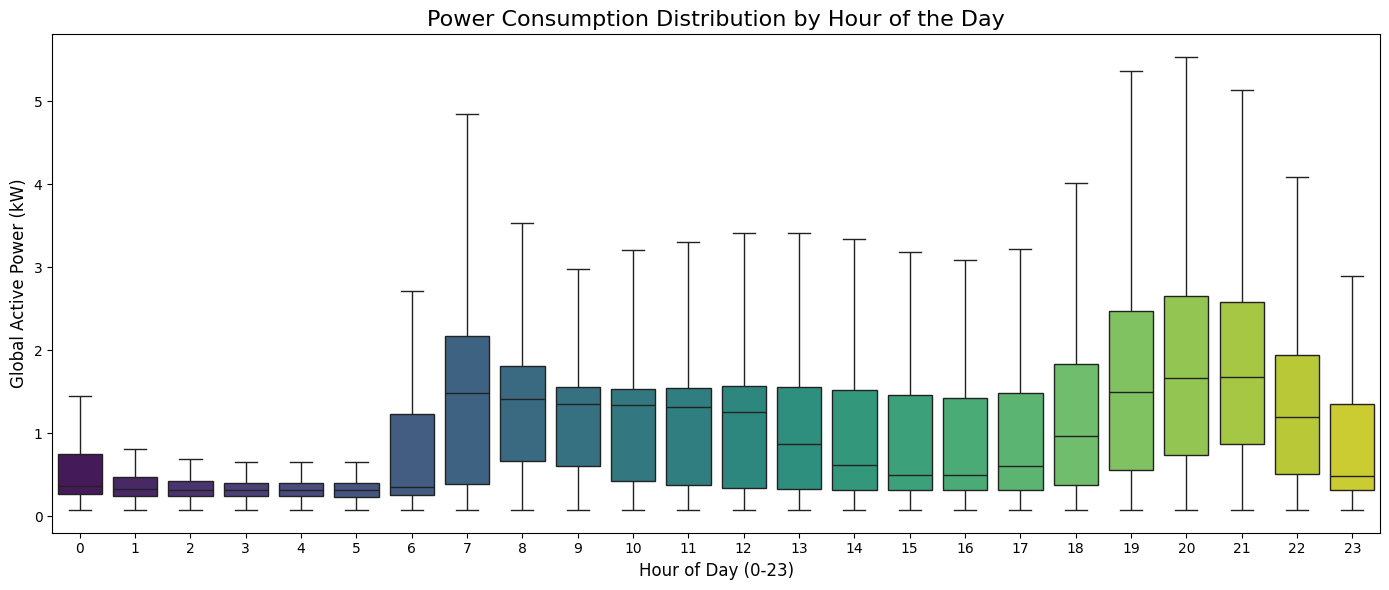

In [17]:
df['Hour'] = df.index.hour

plt.figure(figsize=(14, 6))
# showfliers=False removes extreme outliers to make the boxes easier to read
sns.boxplot(x='Hour', y='Global_active_power', data=df, showfliers=False, palette='viridis')
plt.title('Power Consumption Distribution by Hour of the Day', fontsize=16)
plt.xlabel('Hour of Day (0-23)', fontsize=12)
plt.ylabel('Global Active Power (kW)', fontsize=12)
plt.tight_layout()
plt.show()

# Clean up the temporary column
df.drop('Hour', axis=1, inplace=True)

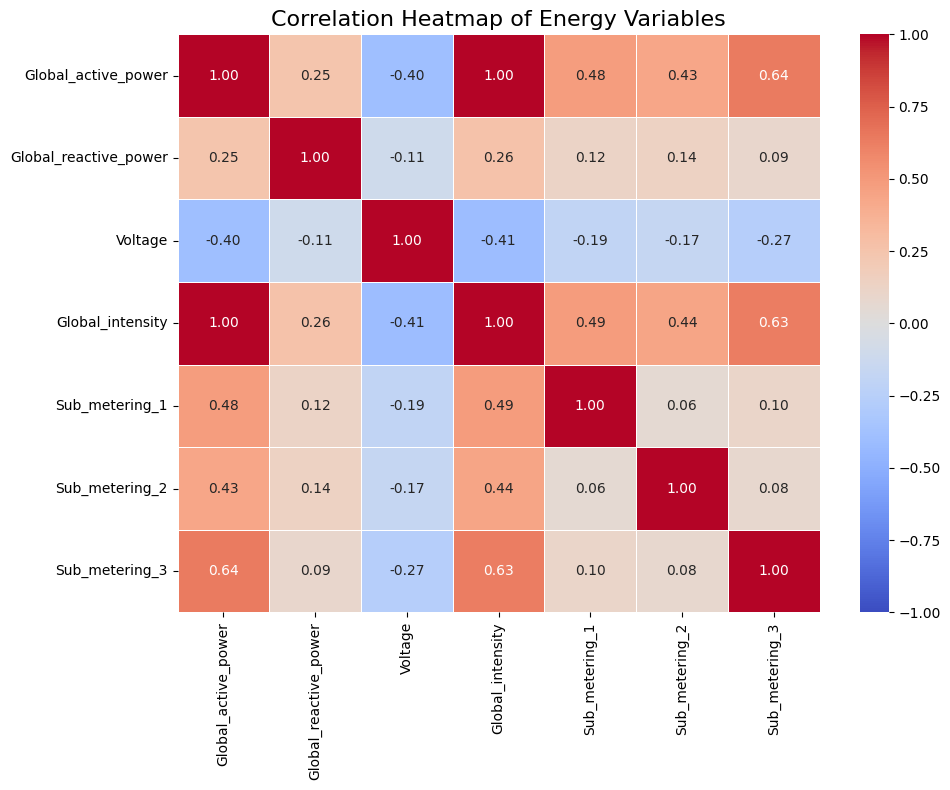

In [18]:
plt.figure(figsize=(10, 8))
corr_matrix = df.corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)
plt.title('Correlation Heatmap of Energy Variables', fontsize=16)
plt.tight_layout()
plt.show()

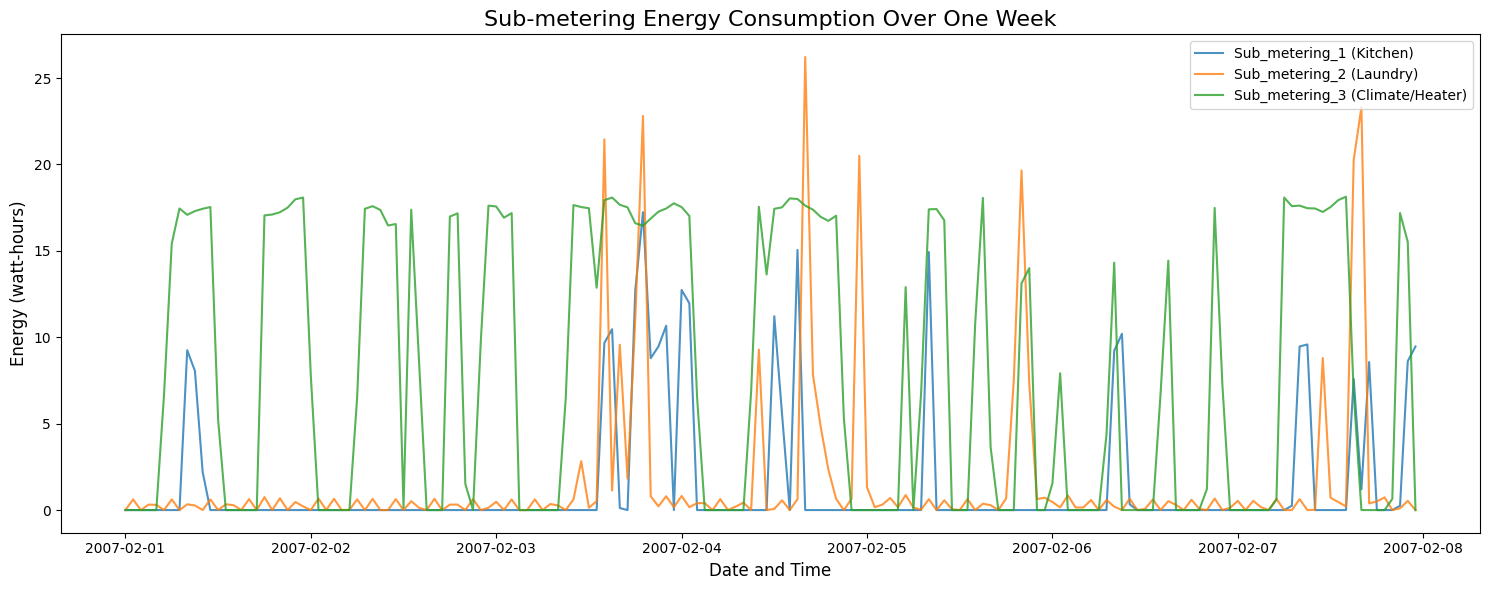

In [19]:
plt.figure(figsize=(15, 6))

# Slice one week of data for clarity
subset = df.loc['2007-02-01':'2007-02-07']
subset_sampled = subset.resample('h').mean()

plt.plot(subset_sampled.index, subset_sampled['Sub_metering_1'], label='Sub_metering_1 (Kitchen)', alpha=0.8)
plt.plot(subset_sampled.index, subset_sampled['Sub_metering_2'], label='Sub_metering_2 (Laundry)', alpha=0.8)
plt.plot(subset_sampled.index, subset_sampled['Sub_metering_3'], label='Sub_metering_3 (Climate/Heater)', alpha=0.8)

plt.title('Sub-metering Energy Consumption Over One Week', fontsize=16)
plt.xlabel('Date and Time', fontsize=12)
plt.ylabel('Energy (watt-hours)', fontsize=12)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

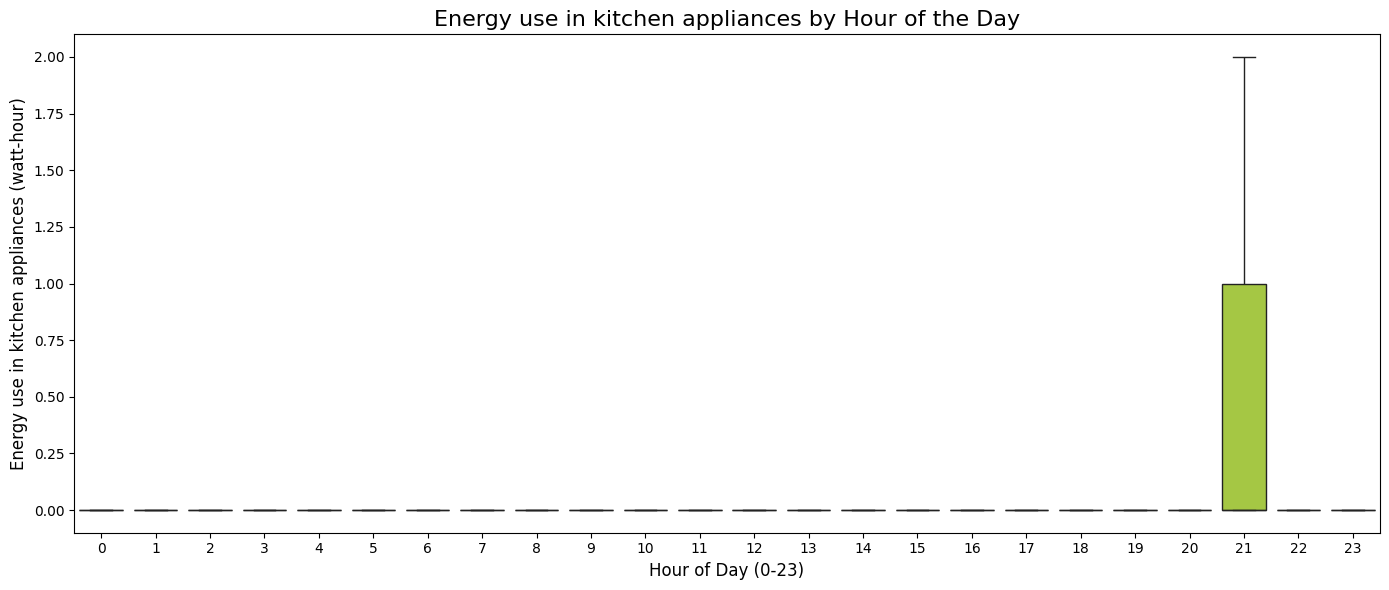

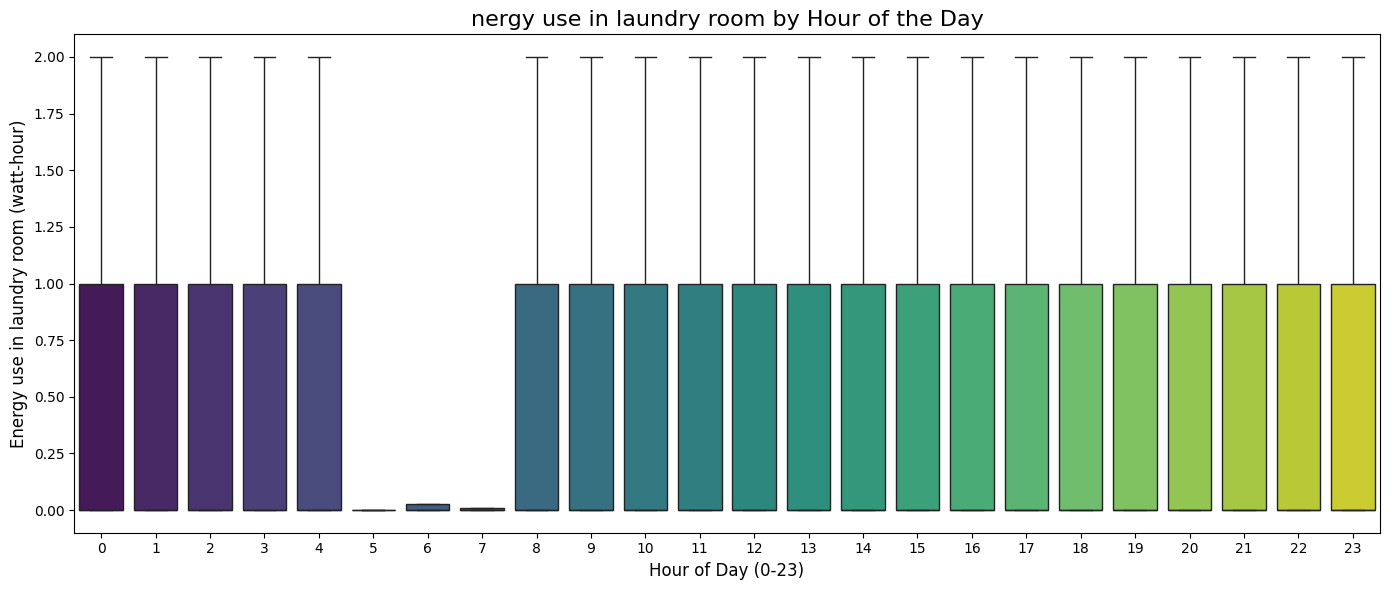

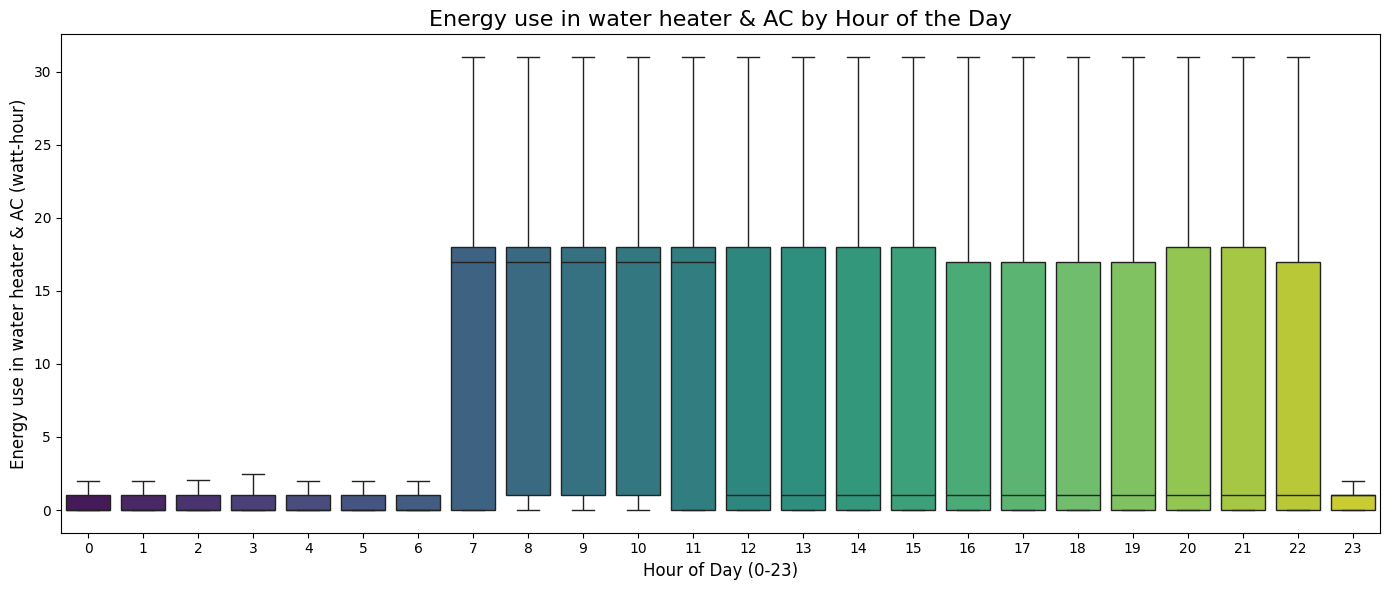

In [20]:
df['Hour'] = df.index.hour

plt.figure(figsize=(14, 6))
# showfliers=False removes extreme outliers to make the boxes easier to read
sns.boxplot(x='Hour', y='Sub_metering_1', data=df, showfliers=False, palette='viridis')
plt.title('Energy use in kitchen appliances by Hour of the Day', fontsize=16)
plt.xlabel('Hour of Day (0-23)', fontsize=12)
plt.ylabel('Energy use in kitchen appliances (watt-hour)', fontsize=12)
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 6))
# showfliers=False removes extreme outliers to make the boxes easier to read
sns.boxplot(x='Hour', y='Sub_metering_2', data=df, showfliers=False, palette='viridis')
plt.title('nergy use in laundry room by Hour of the Day', fontsize=16)
plt.xlabel('Hour of Day (0-23)', fontsize=12)
plt.ylabel('Energy use in laundry room (watt-hour)', fontsize=12)
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 6))
# showfliers=False removes extreme outliers to make the boxes easier to read
sns.boxplot(x='Hour', y='Sub_metering_3', data=df, showfliers=False, palette='viridis')
plt.title('Energy use in water heater & AC by Hour of the Day', fontsize=16)
plt.xlabel('Hour of Day (0-23)', fontsize=12)
plt.ylabel('Energy use in water heater & AC (watt-hour)', fontsize=12)
plt.tight_layout()
plt.show()

# Clean up the temporary column
df.drop('Hour', axis=1, inplace=True)

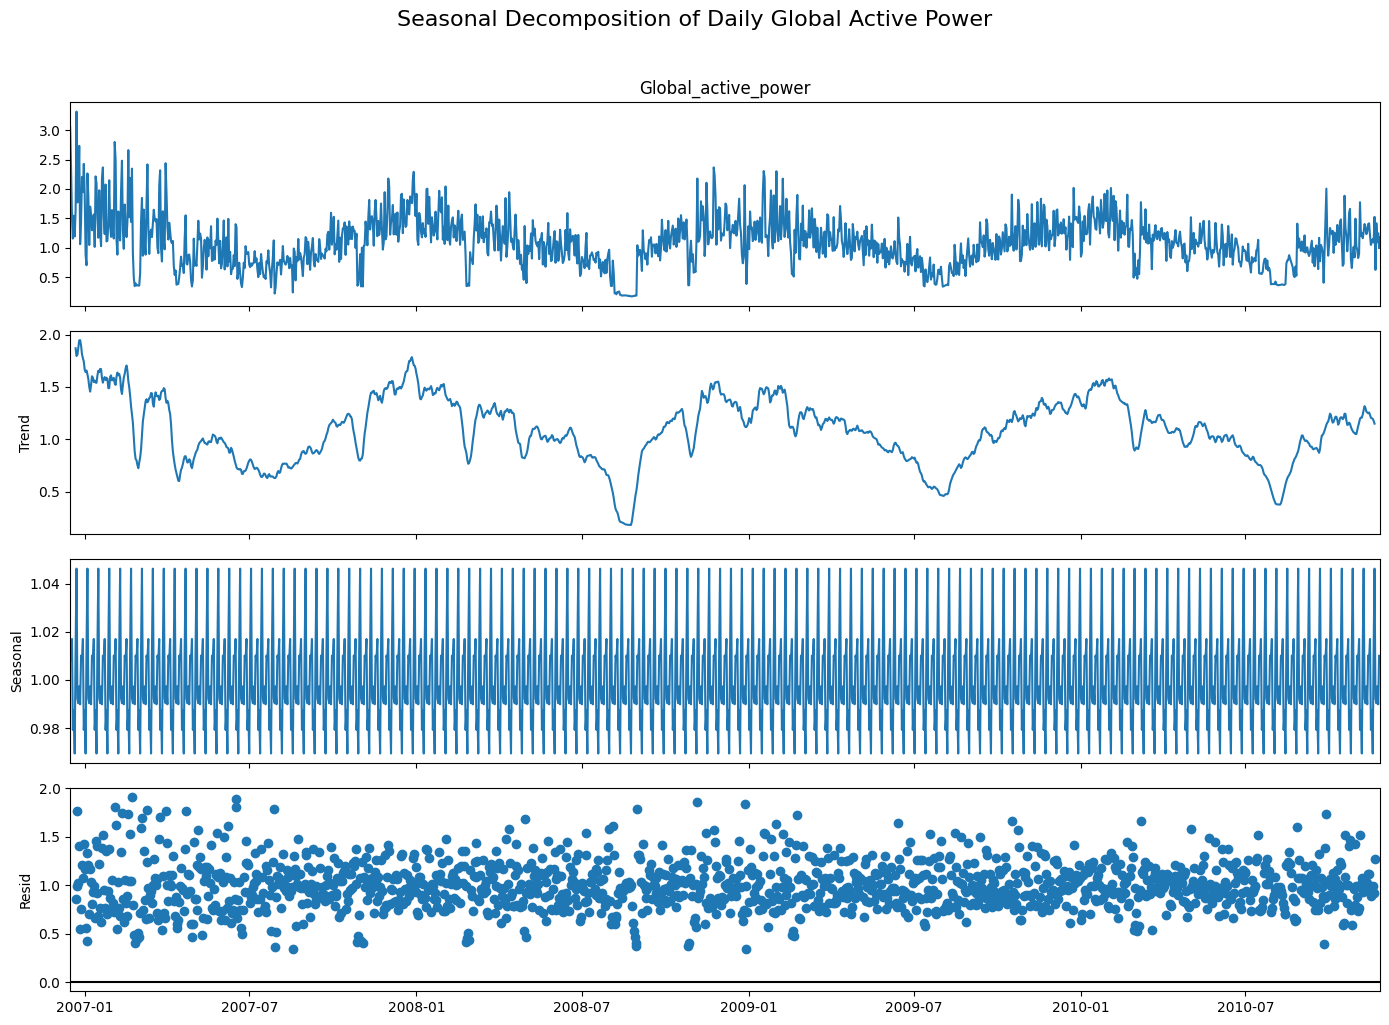

In [21]:
from statsmodels.tsa.seasonal import seasonal_decompose

# 1. Resample to daily averages to reduce noise and computation time
daily_data = df['Global_active_power'].resample('D').mean()

# Drop any potential NaNs created during resampling just to be safe
daily_data = daily_data.dropna()

# 2. Perform seasonal decomposition
# We use period=365 because we are looking for a yearly repeating pattern in daily data
decomposition = seasonal_decompose(daily_data, model='multiplicative', period=12)

# 3. Plot the decomposed components
fig = decomposition.plot()
fig.set_size_inches(14, 10)

# Add a main title
plt.suptitle('Seasonal Decomposition of Daily Global Active Power', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

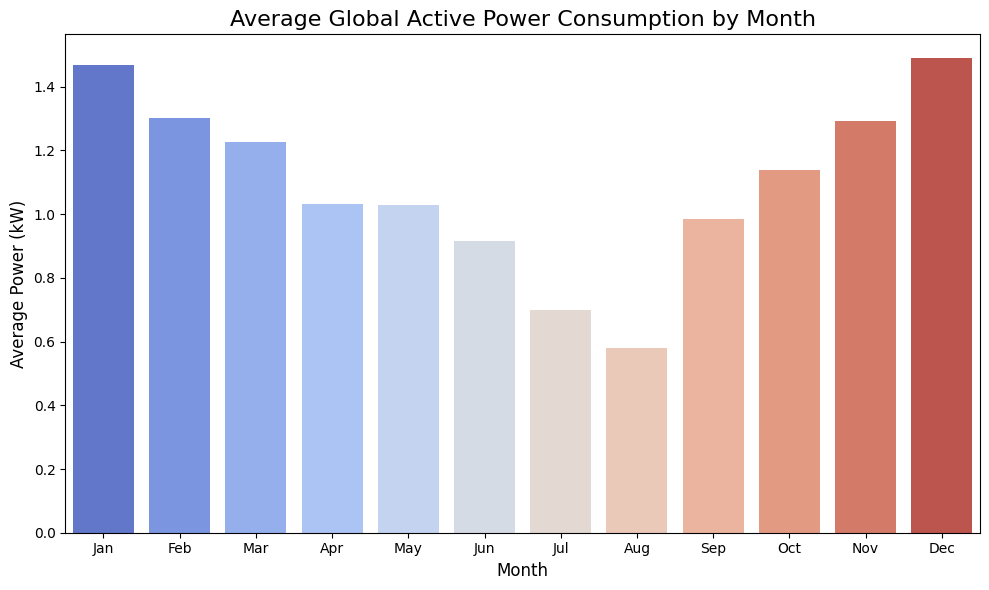

In [22]:

# 1. Extract the month from the Datetime index into a temporary column
df['Month'] = df.index.month

# 2. Calculate the average power consumption for each month across all years
monthly_avg = df.groupby('Month')['Global_active_power'].mean()

# 3. Plot the data
plt.figure(figsize=(10, 6))
sns.barplot(x=monthly_avg.index, y=monthly_avg.values, palette='coolwarm')

plt.title('Average Global Active Power Consumption by Month', fontsize=16)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Average Power (kW)', fontsize=12)

# Replace numeric x-ticks with month names for better readability
plt.xticks(ticks=range(0, 12), 
           labels=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                   'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])

plt.tight_layout()
plt.show()

# 4. Clean up the temporary column to keep your dataframe tidy
df.drop('Month', axis=1, inplace=True)

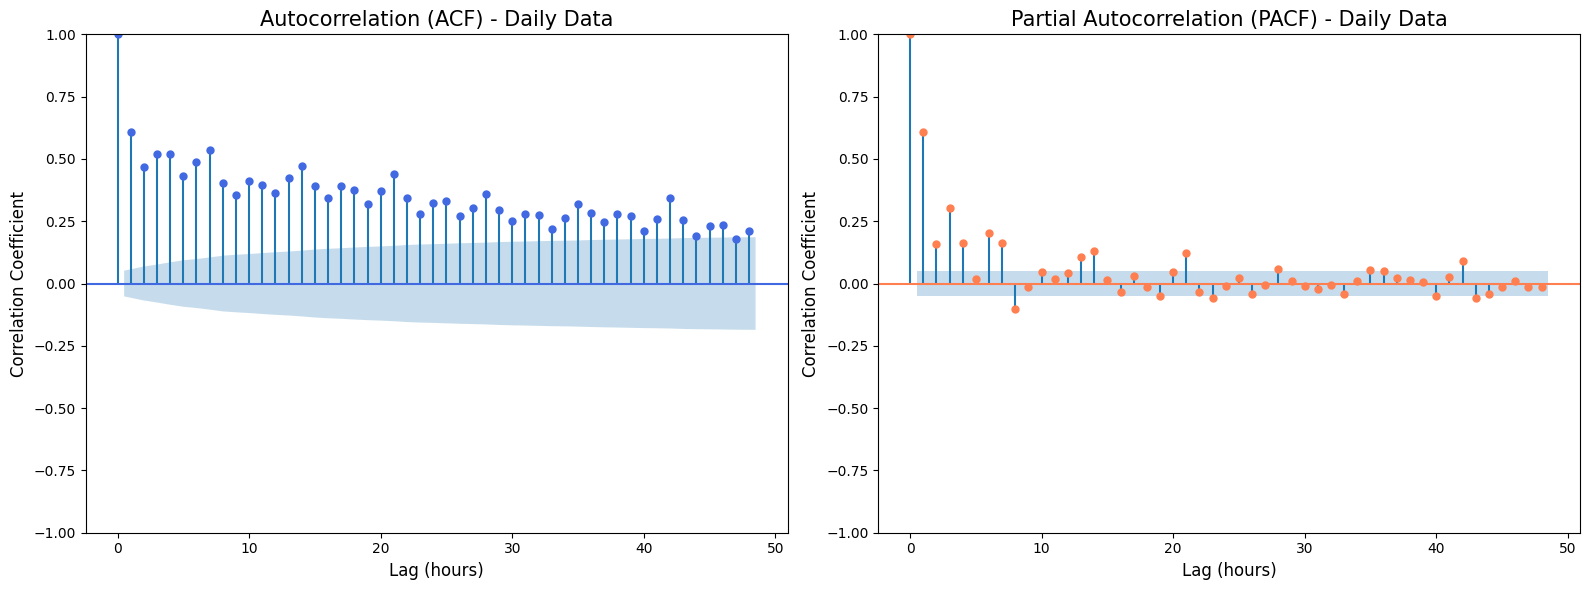

In [23]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# 1. Resample to daily average to look for clear weekly patterns
hourly_data = df['Global_active_power'].resample('h').mean().dropna()

# 2. Set up the figure with two side-by-side subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 3. Plot ACF (Autocorrelation)
# Using lags=35 allows us to look exactly 5 weeks into the past (5 * 7 days)
plot_acf(daily_data, lags=48, ax=axes[0], color='royalblue', alpha=0.05)
axes[0].set_title('Autocorrelation (ACF) - Daily Data', fontsize=15)
axes[0].set_xlabel('Lag (hours)', fontsize=12)
axes[0].set_ylabel('Correlation Coefficient', fontsize=12)

# 4. Plot PACF (Partial Autocorrelation)
plot_pacf(daily_data, lags=48, ax=axes[1], color='coral', alpha=0.05, method='ywm')
axes[1].set_title('Partial Autocorrelation (PACF) - Daily Data', fontsize=15)
axes[1].set_xlabel('Lag (hours)', fontsize=12)
axes[1].set_ylabel('Correlation Coefficient', fontsize=12)

plt.tight_layout()
plt.show()